In [26]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [3]:
df = pd.read_csv("Dataset.csv")

print(df.shape)
df.head()

(9551, 21)


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [4]:
print(df.isnull().sum())

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64


In [5]:
df.dropna(subset=['Cuisines'], inplace=True)

print(df.isnull().sum())

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                0
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64


In [6]:
df['Recommendation_Features'] = (
    df['Cuisines'].astype(str) + " " +
    df['Price range'].astype(str)
)

In [7]:
df[['Restaurant Name',
    'Recommendation_Features']].head()

,Restaurant Name,Recommendation_Features
0,Le Petit Souffle,"French, Japanese, Desserts 3"
1,Izakaya Kikufuji,Japanese 3
2,Heat - Edsa Shangri-La,"Seafood, Asian, Filipino, Indian 4"
3,Ooma,"Japanese, Sushi 4"
4,Sambo Kojin,"Japanese, Korean 4"


In [8]:
tfidf = TfidfVectorizer()

tfidf_matrix = tfidf.fit_transform(
    df['Recommendation_Features']
)

print(tfidf_matrix.shape)

(9542, 150)


In [9]:
cosine_sim = cosine_similarity(
    tfidf_matrix,
    tfidf_matrix
)

print(cosine_sim.shape)

(9542, 9542)


In [10]:
indices = pd.Series(
    df.index,
    index=df['Restaurant Name']
).drop_duplicates()

print(indices.head())

Restaurant Name
Le Petit Souffle          0
Izakaya Kikufuji          1
Heat - Edsa Shangri-La    2
Ooma                      3
Sambo Kojin               4
dtype: int64


In [11]:
print(df.shape)
print(tfidf_matrix.shape)
print(cosine_sim.shape)

(9542, 22)
(9542, 150)
(9542, 9542)


In [17]:
def recommend_restaurants(restaurant_name, top_n=5):

    if restaurant_name not in indices:
        return "Restaurant not found!"

    idx = indices[restaurant_name]

    similarity_scores = list(
        enumerate(cosine_sim[idx])
    )

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    similarity_scores = similarity_scores[1:top_n+1]

    restaurant_indices = [
        i[0] for i in similarity_scores
    ]

    return df[
        ['Restaurant Name',
            'Cuisines',
            'Price range']
    ].iloc[restaurant_indices]

In [18]:
print(df['Restaurant Name'].head(20))

0                             Le Petit Souffle
1                             Izakaya Kikufuji
2                       Heat - Edsa Shangri-La
3                                         Ooma
4                                  Sambo Kojin
5                                 Din Tai Fung
6                                   Buffet 101
7                                      Vikings
8     Spiral - Sofitel Philippine Plaza Manila
9                                     Locavore
10                            Silantro Fil-Mex
11             Mad Mark's Creamery & Good Eats
12                            Silantro Fil-Mex
13                                  Guevarra's
14                     Sodam Korean Restaurant
15                               Cafe Arabelle
16                    Nonna's Pasta & Pizzeria
17                                  Balay Dako
18                  Hobing Korean Dessert Cafe
19                     Wildflour Cafe + Bakery
Name: Restaurant Name, dtype: object


In [19]:
recommend_restaurants("Cafe Arabelle")

,Restaurant Name,Cuisines,Price range
9,Locavore,Filipino,3
13,Guevarra's,Filipino,3
17,Balay Dako,Filipino,3
10,Silantro Fil-Mex,"Filipino, Mexican",3
12,Silantro Fil-Mex,"Filipino, Mexican",3


In [22]:
recommend_restaurants("Le Petit Souffle")

,Restaurant Name,Cuisines,Price range
4993,Tokyo Mon Amour,"Japanese, French",4
70,Paris 6 Classique,French,4
259,Django,French,3
460,Jaan,French,4
461,Rhubarb Le Restaurant,French,4


In [24]:
recommend_restaurants("Mad Mark's Creamery & Good Eats")

,Restaurant Name,Cuisines,Price range
653,Cryo Lab,"Desserts, Ice Cream",2
843,Cream Stone,"Desserts, Ice Cream",1
893,Giani's,"Ice Cream, Desserts",1
898,Gelato Vinto,"Desserts, Ice Cream",1
918,Giani's,"Ice Cream, Desserts",1


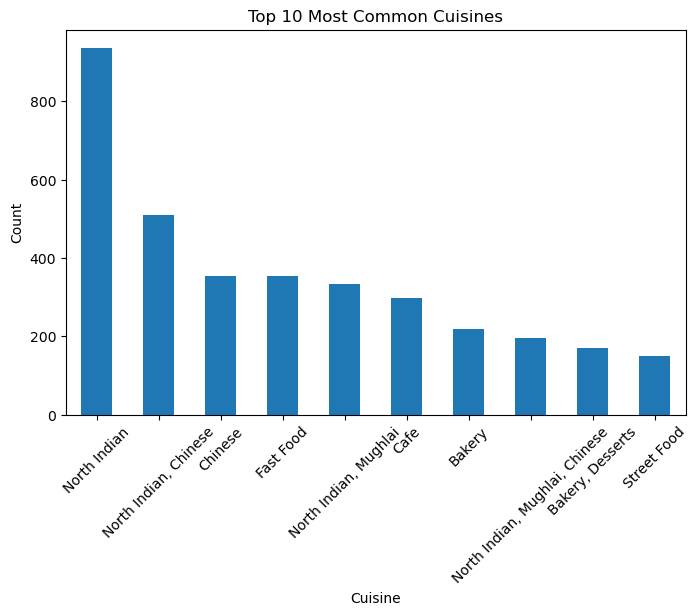

In [27]:
top_cuisines = df['Cuisines'].value_counts().head(10)

plt.figure(figsize=(8,5))
top_cuisines.plot(kind='bar')
plt.title('Top 10 Most Common Cuisines')
plt.xlabel('Cuisine')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

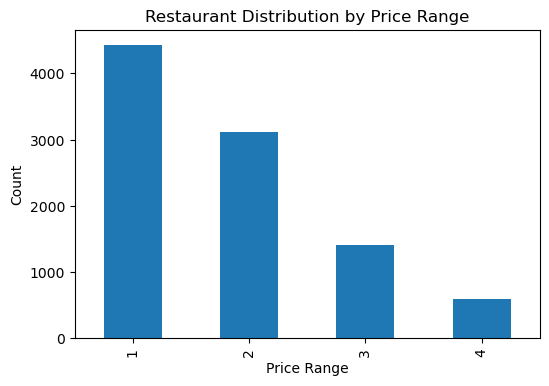

In [28]:
price_counts = df['Price range'].value_counts().sort_index()

plt.figure(figsize=(6,4))
price_counts.plot(kind='bar')
plt.title('Restaurant Distribution by Price Range')
plt.xlabel('Price Range')
plt.ylabel('Count')
plt.show()